# Gleichgewichts-CH₄-Umsatz (Reforming) — Funktion von T und p
Steam Reforming of Methane (SMR): CH₄ + H₂O → 1 CO + 3 H

Dry Reforming of Methane (DRM): CH₄ + CO₂ → 2 CO + 2 H₂

Partial Oxidation reaction (POx) in Autothermal Reforming (ATR): CH₄ + 0.5 O₂ → CO + 2 H₂


 
Berechnung mit **Cantera** (GRI30-Mechanismus)

## 1. Bibliotheken importieren

In [1]:
import cantera as ct
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import scipy
print(scipy.__version__)

# Schöne Plots im Notebook anzeigen
%matplotlib inline
matplotlib.rcParams.update({'font.size': 11})

print(f"Cantera Version: {ct.__version__}")

1.17.1
Cantera Version: 3.2.0


## 2. Einstellungen (Feed, Temperatur- & Druckbereich)

In [2]:
# --- Feed: CH4 + CO2 (Dry Reforming) ---
# Spezies-Reihenfolge: H2, N2, CO, CO2, CH4, C2H6, H2O, O2
#                      0    1   2   3    4    5     6    7
N_in = np.array([0, 0, 0, 0, 1, 0, 2.5, 0])
x_in = N_in / N_in.sum()   # Molenbrüche (normiert)

species_names = ['H2', 'N2', 'CO', 'CO2', 'CH4', 'C2H6', 'H2O', 'O2']
X_dict = {sp: xi for sp, xi in zip(species_names, x_in)}
print("Einsatzzusammensetzung (Molenbrüche):", X_dict)

# --- Temperaturbereich ---
T_in   = 273.15   # K
T_end  = 1600.0   # K
dT     = 20.0     # K
T_range = np.arange(T_in, T_end + dT, dT)   # in K
nT = len(T_range)

# --- Druckbereich: 1 bar, 5 bar, 10 bar dann 20, 40, ...---
p_end = 200      # bar
p_bar_vals = np.concatenate(([1, 5, 10], np.arange(20, p_end+1, 20)))   # in bar
p_vec      = p_bar_vals * 1e5                                # in Pa
np_        = len(p_vec)                                      # Anzahl Druckpunkte (= 21)

print(f"Temperaturbereich: {T_range[0]-273.15:.0f} – {T_range[-1]-273.15:.0f} °C  ({nT} Punkte)")
print(f"Druckbereich:      {p_vec[0]/1e5:.1f} – {p_vec[-1]/1e5:.1f} bar  ({np_} Punkte)")

Einsatzzusammensetzung (Molenbrüche): {'H2': np.float64(0.0), 'N2': np.float64(0.0), 'CO': np.float64(0.0), 'CO2': np.float64(0.0), 'CH4': np.float64(0.2857142857142857), 'C2H6': np.float64(0.0), 'H2O': np.float64(0.7142857142857143), 'O2': np.float64(0.0)}
Temperaturbereich: 0 – 1340 °C  (68 Punkte)
Druckbereich:      1.0 – 200.0 bar  (13 Punkte)


## 3. Cantera-Gasobjekt initialisieren

In [3]:
g = ct.Solution('gri30.yaml')

# Anfangszustand setzen
g.TPX = T_range[0], p_vec[0], X_dict

# Eingangs-Massenanteil CH4 speichern (Referenz für Umsatzberechnung)
w_CH4_in = g['CH4'].Y[0]
print(f"Eingangs-Massenanteil CH4: {w_CH4_in:.4f}")

Eingangs-Massenanteil CH4: 0.2627


## 4. Gleichgewichtsumsatz (Annahme: ideales Gas, Cantera behandelt mit GRI30 die Gasphase als ideales Gasgemisch)

In [4]:
# --- Gleichgewichtsberechnung — 2D über (p, T) ---
Xconv = np.full((np_, nT), np.nan) # Ergebnismatrix vorbelegen

for ip, p_now in enumerate(p_vec): # Schleife über p und T für jeweilige Conversion
    for it, T_now in enumerate(T_range):
        try:
            g.TPX = T_now, p_now, X_dict   # Zustand setzen
            g.equilibrate('TP')            # Gleichgewicht bei (T, p)

            w_CH4 = g['CH4'].Y[0]
            umsatz = (w_CH4_in - w_CH4) / w_CH4_in
            Xconv[ip, it] = np.clip(umsatz, 0.0, 1.0)   # auf [0,1] begrenzen
        except Exception:
            Xconv[ip, it] = np.nan   # bei extremen Bedingungen

print("Berechnung abgeschlossen ✓")
print(f"  Min. Umsatz: {np.nanmin(Xconv):.3f}")
print(f"  Max. Umsatz: {np.nanmax(Xconv):.3f}")

Berechnung abgeschlossen ✓
  Min. Umsatz: 0.000
  Max. Umsatz: 1.000


Berechnung abgeschlossen ✓
  Min. Umsatz: 0.000
  Max. Umsatz: 1.000


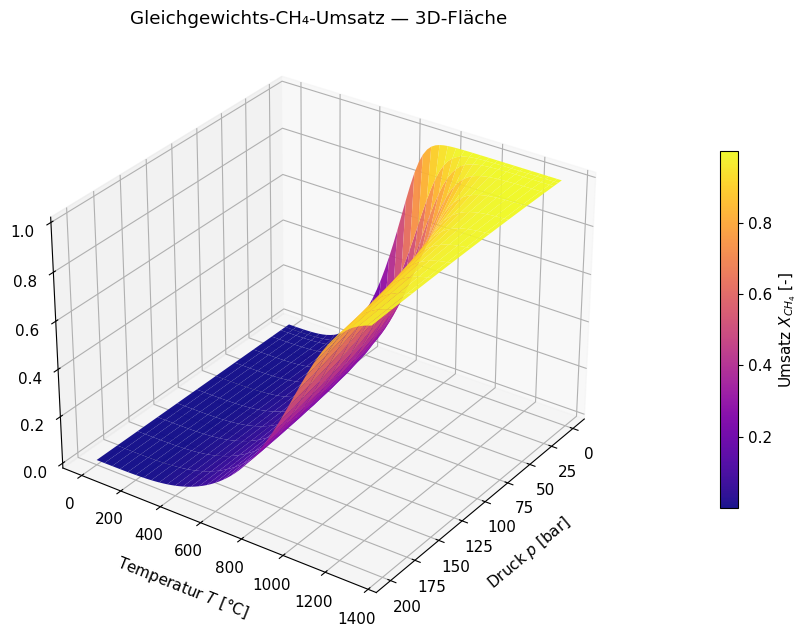

Plot gespeichert: CH4_conv_Tp_surface.pdf


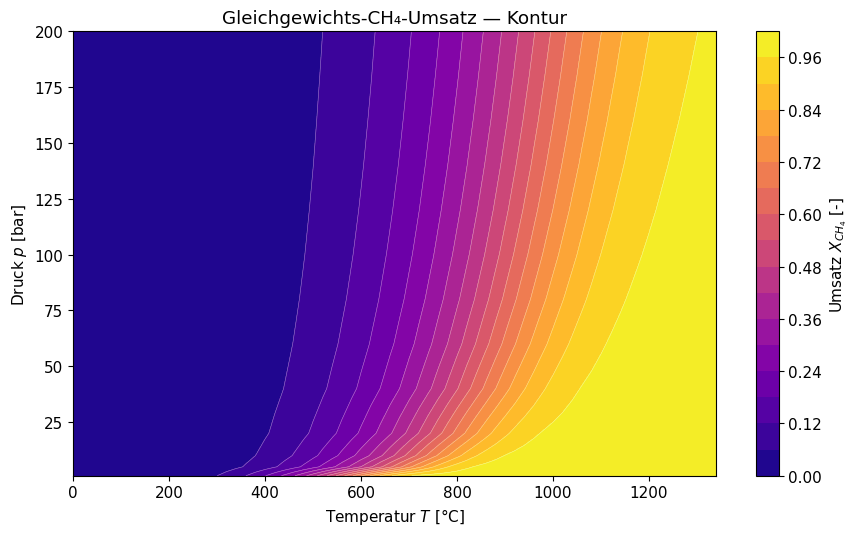

Plot gespeichert: CH4_conv_Tp_contour.pdf


In [5]:
# --- Gleichgewichtsberechnung — 2D über (p, T) ---
Xconv = np.full((np_, nT), np.nan) # Ergebnismatrix vorbelegen

for ip, p_now in enumerate(p_vec): # Schleife über p und T für jeweilige Conversion
    for it, T_now in enumerate(T_range):
        try:
            g.TPX = T_now, p_now, X_dict   # Zustand setzen
            g.equilibrate('TP')            # Gleichgewicht bei (T, p)

            w_CH4 = g['CH4'].Y[0]
            umsatz = (w_CH4_in - w_CH4) / w_CH4_in
            Xconv[ip, it] = np.clip(umsatz, 0.0, 1.0)   # auf [0,1] begrenzen
        except Exception:
            Xconv[ip, it] = np.nan   # bei extremen Bedingungen

print("Berechnung abgeschlossen ✓")
print(f"  Min. Umsatz: {np.nanmin(Xconv):.3f}")
print(f"  Max. Umsatz: {np.nanmax(Xconv):.3f}")


# --- Gitterkoordinaten für Plots ---
T_C   = T_range - 273.15     # Kelvin → °C
p_bar = p_vec / 1e5          # Pa → bar

T_grid, P_grid = np.meshgrid(T_C, p_bar)


# --- 3D-Oberflächenplot der Reaktionsenthalpie ---
fig1, ax1 = plt.subplots(subplot_kw={'projection': '3d'}, figsize=(9, 6.5))

surf = ax1.plot_surface(P_grid.T, T_grid.T, Xconv.T,
                        cmap='plasma', edgecolor='none', alpha=0.95)

ax1.set_xlabel('Druck $p$ [bar]',     labelpad=10)
ax1.set_ylabel('Temperatur $T$ [°C]', labelpad=10)
ax1.set_zlabel('Umsatz $X_{CH_4}$ [-]', labelpad=10)
ax1.set_title('Gleichgewichts-CH₄-Umsatz — 3D-Fläche')
ax1.view_init(elev=30, azim=35)

cbar1 = fig1.colorbar(surf, ax=ax1, pad=0.12, shrink=0.6)
cbar1.set_label('Umsatz $X_{CH_4}$ [-]')

plt.tight_layout()
fig1.savefig('CH4_conv_Tp_surface.pdf', dpi=150)
plt.show()
print("Plot gespeichert: CH4_conv_Tp_surface.pdf")

# --- Heatmap (Konturplot) ---
fig2, ax2 = plt.subplots(figsize=(9, 5.5))

cf = ax2.contourf(T_grid, P_grid, Xconv, levels=18, cmap='plasma')
cs = ax2.contour( T_grid, P_grid, Xconv, levels=18, colors='white', linewidths=0.4, alpha=0.5)

ax2.set_xlabel('Temperatur $T$ [°C]')
ax2.set_ylabel('Druck $p$ [bar]')
ax2.set_title('Gleichgewichts-CH₄-Umsatz — Kontur')

cbar2 = fig2.colorbar(cf, ax=ax2)
cbar2.set_label('Umsatz $X_{CH_4}$ [-]')

plt.tight_layout()
fig2.savefig('CH4_conv_Tp_contour.pdf', dpi=150)
plt.show()
print("Plot gespeichert: CH4_conv_Tp_contour.pdf")

## 5. Reaktionsenthalpie (Annahme: ideales Gas, Cantera behandelt mit GRI30 die Gasphase als ideales Gasgemisch)

Berechnung abgeschlossen ✓
  Min ΔH:     0.0 kJ/mol
  Max ΔH:   221.0 kJ/mol


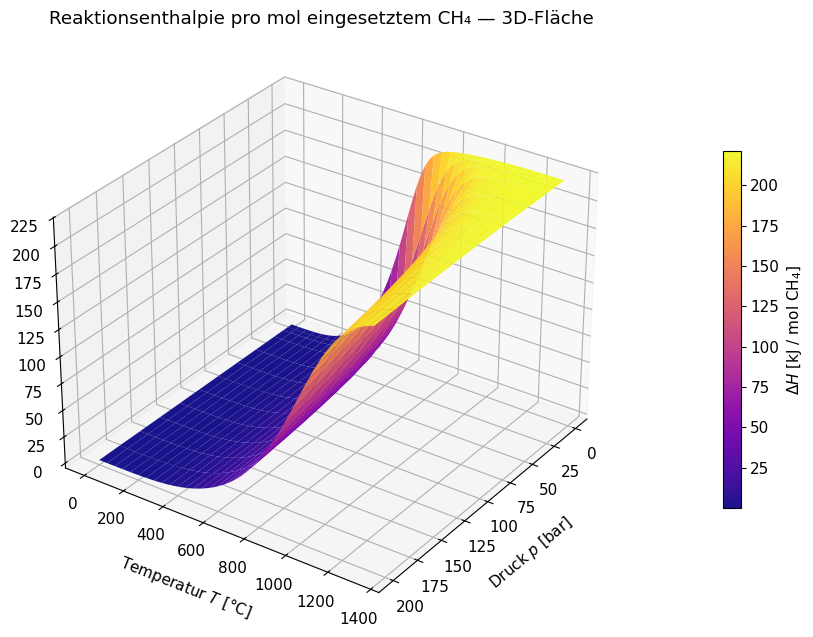

Plot gespeichert: Reaktionsenthalpie_Tp_surface.pdf


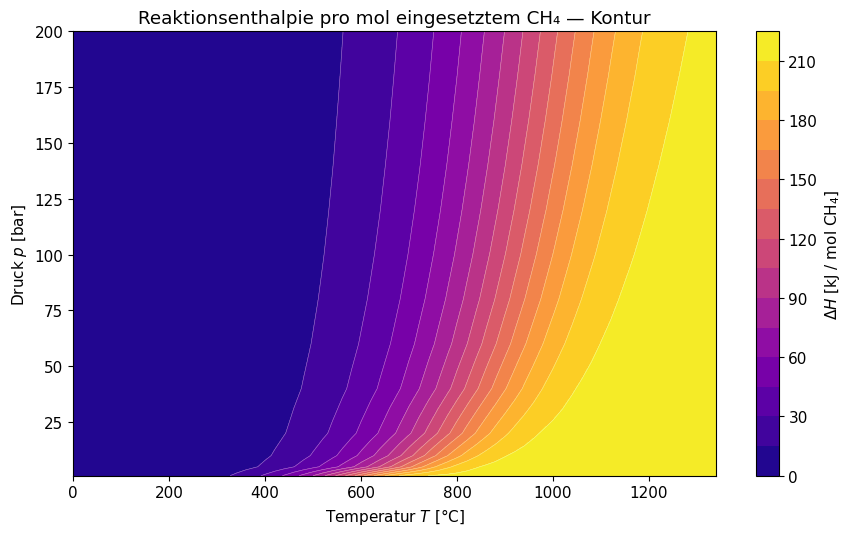

Plot gespeichert: Reaktionsenthalpie_Tp_contour.pdf

Reaktionsenthalpie ΔH [kJ / mol CH₄ eingesetzt]
                    0  100  200   300   400   500    600    700    800    900  \
p [bar] \ T [°C]                                                                
1.0               0.0  0.2  2.2  10.7  32.4  75.1  145.2  202.2  214.9  218.0   
5.0               0.0  0.1  1.2   5.6  17.4  41.0   82.7  146.2  199.2  215.7   
10.0              0.0  0.1  0.9   4.3  13.3  31.3   63.2  115.1  175.7  209.4   
20.0              0.0  0.1  0.7   3.3  10.1  23.9   48.1   88.1  143.8  192.7   
40.0              0.0  0.0  0.5   2.5   7.7  18.2   36.4   66.5  111.8  164.1   
60.0              0.0  0.0  0.4   2.1   6.5  15.5   31.0   56.3   95.1  144.4   
80.0              0.0  0.0  0.4   1.9   5.8  13.8   27.6   50.0   84.5  130.4   
100.0             0.0  0.0  0.4   1.7   5.3  12.6   25.2   45.6   77.0  119.8   
120.0             0.0  0.0  0.3   1.6   5.0  11.8   23.5   42.3   71.3  111.5   
140.0   

In [6]:
# --- Reaktionsenthalpie pro mol eingesetztem CH₄ — 2D über (p, T) ---
# Hinweis: intern wird massenbezogen gerechnet (Masse bleibt erhalten, Stoffmenge nicht!) und am Ende über M_CH4 in mol-Basis umgerechnet.

M_CH4 = 0.01604  # kg/mol

delta_H_mol = np.full((np_, nT), np.nan)   # J / mol CH4 eingesetzt

for ip, p_now in enumerate(p_vec):
    for it, T_now in enumerate(T_range):
        try:
            g.TPX = T_now, p_now, X_dict
            w_CH4_feed = g['CH4'].Y[0]       # kg CH4 / kg Feed
            h_ein = g.enthalpy_mass          # J/kg Feed

            g.equilibrate('TP')
            h_aus = g.enthalpy_mass          # J/kg Produkt

            # (J/kg Feed) · (kg/mol CH4) / (kg CH4/kg Feed)  →  J/mol CH4
            delta_H_mol[ip, it] = (h_aus - h_ein) * M_CH4 / w_CH4_feed
        except Exception:
            pass


# Umrechnung auf kJ/mol für Plot & Tabelle
delta_H_kJmol = delta_H_mol / 1e3

print("Berechnung abgeschlossen ✓")
print(f"  Min ΔH: {np.nanmin(delta_H_kJmol):7.1f} kJ/mol")
print(f"  Max ΔH: {np.nanmax(delta_H_kJmol):7.1f} kJ/mol")


# --- 3D-Oberflächenplot der Reaktionsenthalpie ---
fig4, ax5 = plt.subplots(subplot_kw={'projection': '3d'}, figsize=(9, 6.5))

surf = ax5.plot_surface(P_grid.T, T_grid.T, delta_H_kJmol.T,
                        cmap='plasma', edgecolor='none', alpha=0.95)

ax5.set_xlabel('Druck $p$ [bar]',     labelpad=10)
ax5.set_ylabel('Temperatur $T$ [°C]', labelpad=10)
ax5.set_zlabel(r'$\Delta H$ [kJ / mol CH$_4$]', labelpad=10)
ax5.set_title('Reaktionsenthalpie pro mol eingesetztem CH₄ — 3D-Fläche')
ax5.view_init(elev=30, azim=35)

cbar4 = fig4.colorbar(surf, ax=ax5, pad=0.12, shrink=0.6)
cbar4.set_label(r'$\Delta H$ [kJ / mol CH$_4$]')

plt.tight_layout()
fig4.savefig('Reaktionsenthalpie_Tp_surface.pdf', dpi=150)
plt.show()
print("Plot gespeichert: Reaktionsenthalpie_Tp_surface.pdf")

# --- Heatmap (Konturplot) ---
fig3, ax3 = plt.subplots(figsize=(9, 5.5))

cf = ax3.contourf(T_grid, P_grid, delta_H_kJmol, levels=18, cmap='plasma')
cs = ax3.contour( T_grid, P_grid, delta_H_kJmol, levels=18,
                  colors='white', linewidths=0.4, alpha=0.5)

ax3.set_xlabel('Temperatur $T$ [°C]')
ax3.set_ylabel('Druck $p$ [bar]')
ax3.set_title('Reaktionsenthalpie pro mol eingesetztem CH₄ — Kontur')

cbar3 = fig3.colorbar(cf, ax=ax3)
cbar3.set_label(r'$\Delta H$ [kJ / mol CH$_4$]')

plt.tight_layout()
fig3.savefig('Reaktionsenthalpie_Tp_contour.pdf', dpi=150)
plt.show()
print("Plot gespeichert: Reaktionsenthalpie_Tp_contour.pdf")


# --- Tabelle der zugrundeliegenden Werte ---
df_H = pd.DataFrame(
    delta_H_kJmol,
    index   = [f"{p:.1f}" for p in p_bar],
    columns = [f"{T:.0f}" for T in T_C],
)
df_H.index.name = "p [bar] \\ T [°C]"

# Konsole: kompakter Überblick (jede 5. Temperaturspalte)
print("\nReaktionsenthalpie ΔH [kJ / mol CH₄ eingesetzt]")
print("=" * 72)
print(df_H.iloc[:, ::5].round(1))

Berechnung Δcp abgeschlossen ✓
  Δcp min: -0.0020 J/(mol CH₄ · K)
  Δcp max:  0.0044 J/(mol CH₄ · K)


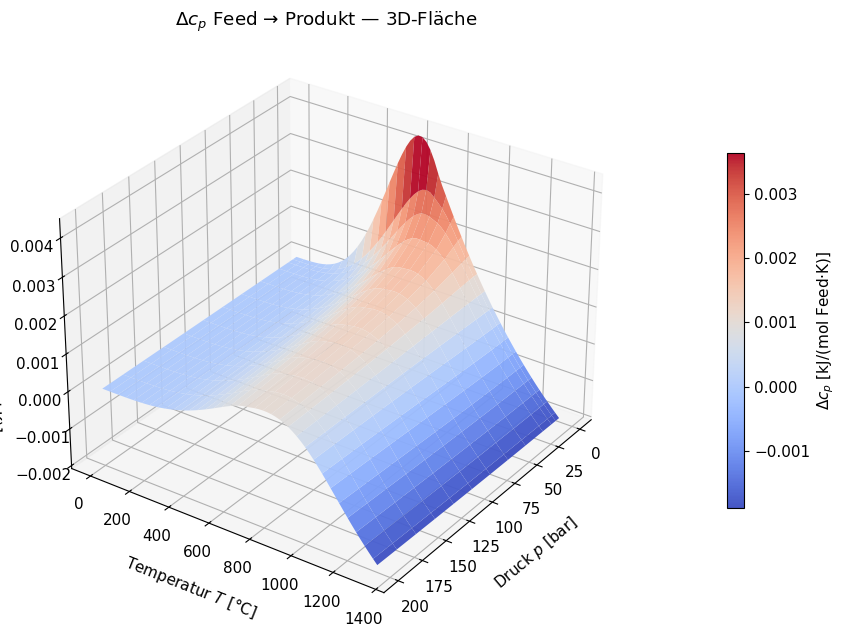

Plot gespeichert: Delta_cp_Tp_surface.pdf


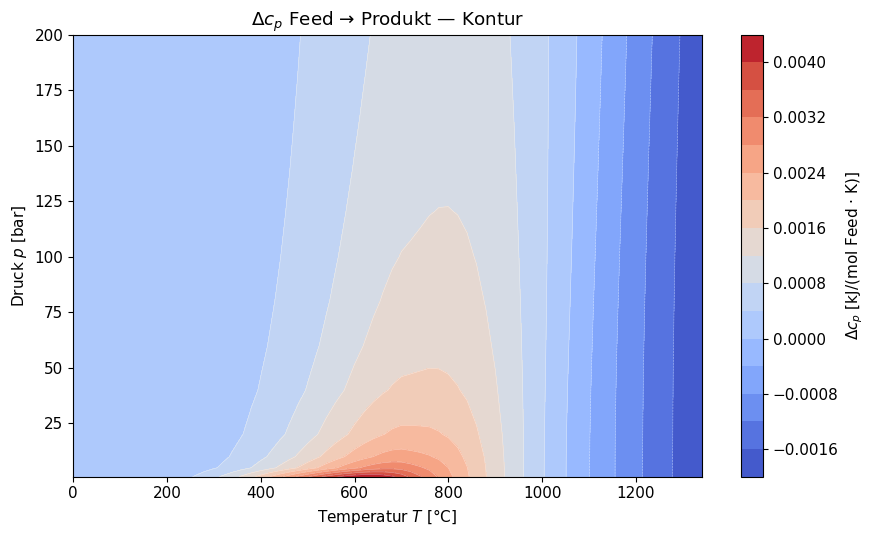

Plot gespeichert: Delta_cp_Tp_contour.pdf

Δcp [kJ / (mol Feed · K)]
                    0  100     200     300     400     500     600     700  \
p [bar] \ T [°C]                                                             
1.0               0.0  0.0  0.0002  0.0007  0.0018  0.0032  0.0043  0.0038   
5.0               0.0  0.0  0.0001  0.0004  0.0009  0.0018  0.0027  0.0031   
10.0              0.0  0.0  0.0001  0.0003  0.0007  0.0014  0.0022  0.0026   
20.0              0.0  0.0  0.0001  0.0002  0.0006  0.0011  0.0017  0.0021   
40.0              0.0  0.0  0.0000  0.0002  0.0004  0.0008  0.0013  0.0017   
60.0              0.0  0.0  0.0000  0.0001  0.0004  0.0007  0.0011  0.0014   
80.0              0.0  0.0  0.0000  0.0001  0.0003  0.0006  0.0010  0.0013   
100.0             0.0  0.0  0.0000  0.0001  0.0003  0.0006  0.0009  0.0012   
120.0             0.0  0.0  0.0000  0.0001  0.0003  0.0005  0.0009  0.0011   
140.0             0.0  0.0  0.0000  0.0001  0.0003  0.0005  0.0008  0.001

In [7]:
# --- Δcp — 2D über (p, T) ---
# cp_feed:    cp des Feeds bei (T,p) — Zusammensetzung fest = X_dict
# cp_produkt: cp des Gleichgewichts-Produktes bei gleichem (T,p)

M_CH4 = 0.01604  # kg/mol

cp_feed      = np.full((np_, nT), np.nan)   # J/(kg Feed · K)
cp_produkt   = np.full((np_, nT), np.nan)   # J/(kg Produkt · K)
delta_cp_mol = np.full((np_, nT), np.nan)   # J/(mol eingesetzt · K)

for ip, p_now in enumerate(p_vec):
    for it, T_now in enumerate(T_range):
        try:
            # Feed-Zustand
            g.TPX = T_now, p_now, X_dict
            cp_in  = g.cp_mass
            M_feed = g.mean_molecular_weight    # kg/kmol — hier abgreifen, solange Feed gesetzt!

            # Gleichgewichts-Zustand
            g.equilibrate('TP')
            cp_out = g.cp_mass

            cp_feed[ip, it]     = cp_in # J/(kg·K)
            cp_produkt[ip, it]  = cp_out # J/(kg·K)
            delta_cp_mol[ip, it] = (cp_out - cp_in)/1000 * (M_feed)/1000 # kJ/(mol Feed·K)
        except Exception:
            pass

print("Berechnung Δcp abgeschlossen ✓")
print(f"  Δcp min: {np.nanmin(delta_cp_mol):7.4f} J/(mol CH₄ · K)")
print(f"  Δcp max: {np.nanmax(delta_cp_mol):7.4f} J/(mol CH₄ · K)")


# --- 3D-Oberflächenplot ---
fig6, ax6 = plt.subplots(subplot_kw={'projection': '3d'}, figsize=(9, 6.5))

surf6 = ax6.plot_surface(P_grid.T, T_grid.T, delta_cp_mol.T,
                         cmap='coolwarm', edgecolor='none', alpha=0.95)

ax6.set_xlabel('Druck $p$ [bar]',     labelpad=10)
ax6.set_ylabel('Temperatur $T$ [°C]', labelpad=10)
ax6.set_zlabel(r'$\Delta c_p$ [kJ/(mol Feed·K)]', labelpad=10)
ax6.set_title(r'$\Delta c_p$ Feed → Produkt — 3D-Fläche')
ax6.view_init(elev=30, azim=35)

cbar6 = fig6.colorbar(surf6, ax=ax6, pad=0.12, shrink=0.6)
cbar6.set_label(r'$\Delta c_p$ [kJ/(mol Feed·K)]')

plt.tight_layout()
fig6.savefig('Delta_cp_Tp_surface.pdf', dpi=150)
plt.show()
print("Plot gespeichert: Delta_cp_Tp_surface.pdf")

# --- Heatmap (Konturplot) ---
fig5, ax5 = plt.subplots(figsize=(9, 5.5))

cf = ax5.contourf(T_grid, P_grid, delta_cp_mol, levels=18, cmap='coolwarm')
cs = ax5.contour( T_grid, P_grid, delta_cp_mol, levels=18,
                  colors='white', linewidths=0.4, alpha=0.5)

ax5.set_xlabel('Temperatur $T$ [°C]')
ax5.set_ylabel('Druck $p$ [bar]')
ax5.set_title(r'$\Delta c_p$ Feed → Produkt — Kontur')

cbar5 = fig5.colorbar(cf, ax=ax5)
cbar5.set_label(r'$\Delta c_p$ [kJ/(mol Feed · K)]')

plt.tight_layout()
fig5.savefig('Delta_cp_Tp_contour.pdf', dpi=150)
plt.show()
print("Plot gespeichert: Delta_cp_Tp_contour.pdf")

# --- Tabelle ---
df_cp = pd.DataFrame(
    delta_cp_mol,
    index   = [f"{p:.1f}" for p in p_bar],
    columns = [f"{T:.0f}" for T in T_C],
)
df_cp.index.name = "p [bar] \\ T [°C]"

print("\nΔcp [kJ / (mol Feed · K)]")
print("=" * 72)
print(df_cp.iloc[:, ::5].round(4))


## 5. Reaktionsenthalpie pro mol CH4 umgesetzt

Berechnung abgeschlossen ✓
  Min ΔH:   2.823 MWh / t CH₄ umgesetzt
  Max ΔH:   3.828 MWh / t CH₄ umgesetzt


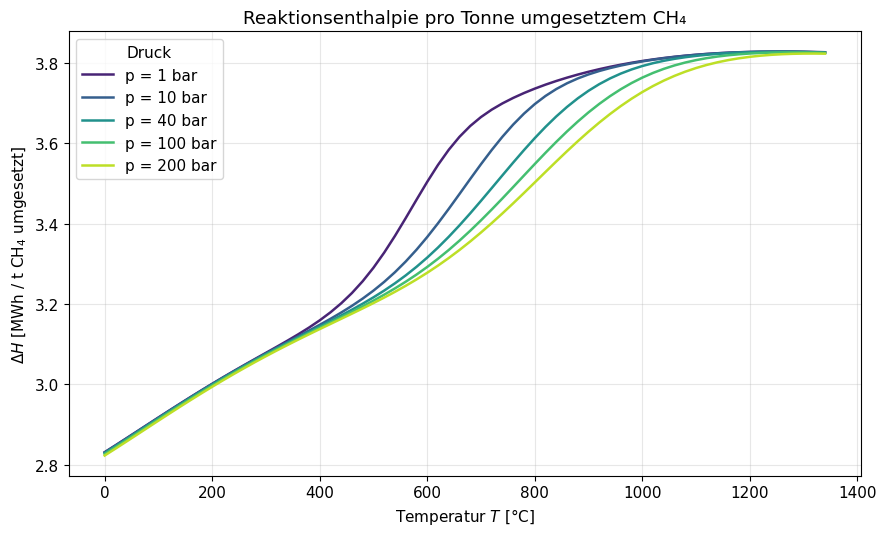

Plot gespeichert: Reaktionsenthalpie_per_t_CH4_umgesetzt.pdf

Rest-p-Abhängigkeit (Spannweite max-min über alle Drücke je T):
  median: 0.0310 MWh/t
  max:    0.2874 MWh/t

ΔH [MWh / t CH₄ umgesetzt] — Statistik über den Druckbereich
 T [°C]  dH mean [MWh/t]  dH std  [MWh/t]  dH min  [MWh/t]  dH max  [MWh/t]
      0           2.8271           0.0028           2.8227           2.8310
    100           2.9136           0.0026           2.9094           2.9173
    200           2.9977           0.0025           2.9938           3.0012
    300           3.0738           0.0026           3.0699           3.0782
    400           3.1434           0.0059           3.1373           3.1591
    500           3.2201           0.0237           3.2021           3.2901
    600           3.3254           0.0628           3.2775           3.5038
    700           3.4588           0.0882           3.3778           3.6651
    800           3.5931           0.0806           3.5023           3.7357
    90

In [8]:
# --- Reaktionsenthalpie pro Tonne UMGESETZTEM CH₄ ---
# Wiederverwendung der bereits berechneten Größen:
#   delta_H_mol [J / mol CH4 eingesetzt]  (aus Abschnitt 5)
#   Xconv       [-]  Umsatz               (aus Abschnitt 4)
#
# delta_H_mol / Xconv = J / mol CH4 umgesetzt   (mathematisch exakt)

M_CH4 = 0.01604  # kg/mol

# Division durch (fast) Null vermeiden
mask = Xconv > 1e-6
dH_MWh_per_t = np.full_like(delta_H_mol, np.nan)
dH_MWh_per_t[mask] = delta_H_mol[mask] / Xconv[mask] / M_CH4 * 1000.0 / 3.6e9
#                    └──── J/mol umges. ────┘ └─J/kg─┘ └kg/t┘ └J→MWh┘

print('Berechnung abgeschlossen ✓')
print(f'  Min ΔH: {np.nanmin(dH_MWh_per_t):7.3f} MWh / t CH₄ umgesetzt')
print(f'  Max ΔH: {np.nanmax(dH_MWh_per_t):7.3f} MWh / t CH₄ umgesetzt')

# --- Plot: ΔH(T) als Kurvenschar für ausgewählte Drücke ---
fig7, ax7 = plt.subplots(figsize=(9, 5.5))

p_show = [1, 10, 50, 100, 200]   # bar
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(p_show)))

for c, p_target in zip(colors, p_show):
    ip = int(np.argmin(np.abs(p_bar - p_target)))
    ax7.plot(T_C, dH_MWh_per_t[ip, :], color=c, lw=1.8,
             label=f'p = {p_bar[ip]:.0f} bar')

ax7.set_xlabel('Temperatur $T$ [°C]')
ax7.set_ylabel(r'$\Delta H$ [MWh / t CH$_4$ umgesetzt]')
ax7.set_title('Reaktionsenthalpie pro Tonne umgesetztem CH₄')
ax7.grid(alpha=0.3)
ax7.legend(title='Druck', loc='best')

plt.tight_layout()
fig7.savefig('Reaktionsenthalpie_per_t_CH4_umgesetzt.pdf', dpi=150)
plt.show()
print('Plot gespeichert: Reaktionsenthalpie_per_t_CH4_umgesetzt.pdf')

# --- Quantifizierung der Rest-p-Abhängigkeit ---
spread = np.nanmax(dH_MWh_per_t, axis=0) - np.nanmin(dH_MWh_per_t, axis=0)
print('\nRest-p-Abhängigkeit (Spannweite max-min über alle Drücke je T):')
print(f'  median: {np.nanmedian(spread):.4f} MWh/t')
print(f'  max:    {np.nanmax(spread):.4f} MWh/t')

# --- Tabelle: Statistik über p je T ---
df_T = pd.DataFrame({
    'T [°C]':           T_C.round(0).astype(int),
    'dH mean [MWh/t]':  np.nanmean(dH_MWh_per_t, axis=0).round(4),
    'dH std  [MWh/t]':  np.nanstd(dH_MWh_per_t,  axis=0).round(4),
    'dH min  [MWh/t]':  np.nanmin(dH_MWh_per_t,  axis=0).round(4),
    'dH max  [MWh/t]':  np.nanmax(dH_MWh_per_t,  axis=0).round(4),
})

print('\nΔH [MWh / t CH₄ umgesetzt] — Statistik über den Druckbereich')
print('=' * 72)
print(df_T.iloc[::5].to_string(index=False))

## 6. Delta H Ergebnis für high level Abatement Effectiveness

In [9]:
import cantera as ct
import numpy as np

M_CH4 = 0.01604  # kg/mol

g2 = ct.Solution('gri30.yaml')

query_points = [(850, 17), (1100, 51)]   # (T in °C, p in bar)

header = (f"{'T [°C]':>8}  {'p [bar]':>8}  {'X_CH4 [-]':>12}"
          f"  {'ΔH [kJ/mol CH4,ein]':>22}  {'ΔH [kJ/mol CH4,umg]':>22}")
print(header)
print("─" * 82)

for T_q, p_q in query_points:
    T_K   = T_q + 273.15
    p_Pa  = p_q * 1e5

    # ── Feed-Zustand ──────────────────────────────────────────────────────
    g2.TPX = T_K, p_Pa, X_dict
    w_CH4_feed = g2['CH4'].Y[0]
    h_ein      = g2.enthalpy_mass        # J/kg Feed

    # ── Gleichgewicht ─────────────────────────────────────────────────────
    g2.equilibrate('TP')
    w_CH4_eq = g2['CH4'].Y[0]
    h_aus    = g2.enthalpy_mass          # J/kg Produkt

    # ── Auswertung ────────────────────────────────────────────────────────
    X_val  = np.clip((w_CH4_feed - w_CH4_eq) / w_CH4_feed, 0.0, 1.0)
    dH_ein = (h_aus - h_ein) * M_CH4 / w_CH4_feed / 1e3   # kJ/mol CH4,ein
    dH_umg = dH_ein / X_val                                # kJ/mol CH4,umg

    print(f"{T_q:>8.0f}  {p_q:>8.0f}  {X_val:>12.4f}"
          f"  {dH_ein:>22.1f}  {dH_umg:>22.1f}")

  T [°C]   p [bar]     X_CH4 [-]     ΔH [kJ/mol CH4,ein]     ΔH [kJ/mol CH4,umg]
──────────────────────────────────────────────────────────────────────────────────
     850        17        0.8291                   178.3                   215.1
    1100        51        0.9659                   212.8                   220.3


## 7. Peng-Robinson Realgas-Modell — Erstellung der YAML-Datei

GRI-Mech 3.0 verwendet standardmaessig das Idealgasmodell (`thermo: ideal-gas`).
Fuer die Realgas-Berechnung wird eine modifizierte YAML-Datei (`gri30_pr.yaml`) erzeugt.

### Herkunft der kritischen Eigenschaften (Tc, Pc, omega)

Von den 53 GRI-Spezies sind **11 in Canteras interner Datenbank** (`critical-properties.yaml`) enthalten.
Cantera liest diese automatisch — es ist kein manueller Eintrag noetig.

| In Canteras DB (automatisch) |
|------------------------------|
| H2, O2, CH4, CO, CO2, CH2O, C2H2, C2H4, C2H6, N2, C3H8 |

Fuer die restlichen **42 Spezies** (darunter H2O, AR, alle Radikale) muessen Werte manuell angegeben werden:
- **Stabile Spezies** (H2O, NH3, AR, NO, NO2, N2O, HCN, CH3OH, CH3CHO ...): Literaturwerte aus NIST WebBook
- **Radikale** (OH, CH3, HCO, NH, NNH ...): Schaetzwerte (Joback-Methode / Analogie zu aehnlichen stabilen Spezies)

> **Hinweis:** Die Schaetzwerte fuer Radikale sind mit Unsicherheit behaftet.
> Da Radikale im Gleichgewicht jedoch nur in ppm-Mengen vorkommen, ist ihr Einfluss auf
> die Realgas-Korrektur vernachlaessigbar. Die relevanten Spezies (CH4, H2O, CO2, CO, H2)
> haben alle zuverlaessige Literaturwerte.

In [ ]:
import re, os, cantera as ct

GRI_PATH = os.path.join(os.path.dirname(ct.__file__), 'data', 'gri30.yaml')
with open(GRI_PATH) as f:
    raw_gri = f.read()

# Quelle je Spezies:
#   'cantera' = automatisch aus Canteras critical-properties.yaml (kein Eintrag noetig)
#   'nist'    = Literaturwert (NIST WebBook / Perry's)
#   'est'     = Schaetzwert  (Joback / Analogie)
#
# In Canteras DB (kein Eintrag noetig):
#   H2, O2, CH4, CO, CO2, CH2O, C2H2, C2H4, C2H6, N2, C3H8

MANUAL_CRIT = {
    # ── NIST-Literaturwerte ────────────────────────────────────────────────
    'H2O':    {'Tc': 647.10,  'Pc': 22.064e6, 'omega':  0.345, 'src': 'nist'},
    'NH3':    {'Tc': 405.56,  'Pc': 11.353e6, 'omega':  0.257, 'src': 'nist'},
    'CH3OH':  {'Tc': 512.64,  'Pc':  8.097e6, 'omega':  0.565, 'src': 'nist'},
    'CH3CHO': {'Tc': 466.00,  'Pc':  5.570e6, 'omega':  0.291, 'src': 'nist'},
    'NO':     {'Tc': 180.00,  'Pc':  6.480e6, 'omega':  0.582, 'src': 'nist'},
    'NO2':    {'Tc': 431.35,  'Pc': 10.010e6, 'omega':  0.825, 'src': 'nist'},
    'N2O':    {'Tc': 309.60,  'Pc':  7.245e6, 'omega':  0.162, 'src': 'nist'},
    'HCN':    {'Tc': 456.65,  'Pc':  5.390e6, 'omega':  0.407, 'src': 'nist'},
    'H2O2':   {'Tc': 728.00,  'Pc': 21.400e6, 'omega':  0.350, 'src': 'nist'},
    'AR':     {'Tc': 150.86,  'Pc':  4.898e6, 'omega': -0.002, 'src': 'nist'},
    'C3H7':   {'Tc': 394.00,  'Pc':  4.300e6, 'omega':  0.160, 'src': 'nist'},
    'CH2CHO': {'Tc': 500.00,  'Pc':  5.500e6, 'omega':  0.350, 'src': 'nist'},
    # ── Schaetzwerte fuer Radikale / kurzlebige Spezies ───────────────────
    'H':      {'Tc':  43.60,  'Pc':  2.040e6, 'omega': -0.220, 'src': 'est'},
    'O':      {'Tc': 154.60,  'Pc':  5.040e6, 'omega':  0.022, 'src': 'est'},
    'C':      {'Tc':6810.00,  'Pc': 22.300e6, 'omega':  0.200, 'src': 'est'},
    'N':      {'Tc': 126.20,  'Pc':  3.400e6, 'omega':  0.037, 'src': 'est'},
    'OH':     {'Tc': 315.00,  'Pc':  8.200e6, 'omega':  0.300, 'src': 'est'},
    'HO2':    {'Tc': 315.00,  'Pc':  8.800e6, 'omega':  0.400, 'src': 'est'},
    'HCO':    {'Tc': 393.00,  'Pc':  6.400e6, 'omega':  0.338, 'src': 'est'},
    'CH2OH':  {'Tc': 480.00,  'Pc':  7.300e6, 'omega':  0.500, 'src': 'est'},
    'CH3O':   {'Tc': 480.00,  'Pc':  7.300e6, 'omega':  0.500, 'src': 'est'},
    'CH':     {'Tc': 280.00,  'Pc':  5.500e6, 'omega':  0.150, 'src': 'est'},
    'CH2':    {'Tc': 330.00,  'Pc':  5.800e6, 'omega':  0.150, 'src': 'est'},
    'CH2(S)': {'Tc': 330.00,  'Pc':  5.800e6, 'omega':  0.150, 'src': 'est'},
    'CH3':    {'Tc': 370.00,  'Pc':  5.700e6, 'omega':  0.150, 'src': 'est'},
    'C2H':    {'Tc': 400.00,  'Pc':  5.800e6, 'omega':  0.200, 'src': 'est'},
    'C2H3':   {'Tc': 350.00,  'Pc':  5.500e6, 'omega':  0.180, 'src': 'est'},
    'C2H5':   {'Tc': 313.00,  'Pc':  4.700e6, 'omega':  0.100, 'src': 'est'},
    'HCCO':   {'Tc': 450.00,  'Pc':  5.500e6, 'omega':  0.300, 'src': 'est'},
    'CH2CO':  {'Tc': 477.00,  'Pc':  5.200e6, 'omega':  0.287, 'src': 'est'},
    'HCCOH':  {'Tc': 460.00,  'Pc':  5.500e6, 'omega':  0.300, 'src': 'est'},
    'NH':     {'Tc': 235.00,  'Pc':  5.800e6, 'omega':  0.200, 'src': 'est'},
    'NH2':    {'Tc': 350.00,  'Pc':  9.200e6, 'omega':  0.250, 'src': 'est'},
    'NNH':    {'Tc': 200.00,  'Pc':  6.000e6, 'omega':  0.150, 'src': 'est'},
    'HNO':    {'Tc': 340.00,  'Pc':  8.500e6, 'omega':  0.350, 'src': 'est'},
    'CN':     {'Tc': 258.00,  'Pc':  5.900e6, 'omega':  0.200, 'src': 'est'},
    'H2CN':   {'Tc': 420.00,  'Pc':  6.500e6, 'omega':  0.350, 'src': 'est'},
    'HCNN':   {'Tc': 420.00,  'Pc':  6.000e6, 'omega':  0.300, 'src': 'est'},
    'HCNO':   {'Tc': 450.00,  'Pc':  6.200e6, 'omega':  0.400, 'src': 'est'},
    'HOCN':   {'Tc': 450.00,  'Pc':  6.200e6, 'omega':  0.400, 'src': 'est'},
    'HNCO':   {'Tc': 460.00,  'Pc':  6.700e6, 'omega':  0.400, 'src': 'est'},
    'NCO':    {'Tc': 380.00,  'Pc':  6.800e6, 'omega':  0.350, 'src': 'est'},
}

# In Canteras Datenbank (kein Eintrag noetig)
CANTERA_DB = ['H2', 'O2', 'CH4', 'CO', 'CO2', 'CH2O',
              'C2H2', 'C2H4', 'C2H6', 'N2', 'C3H8']

def cp_block(name):
    if name not in MANUAL_CRIT:
        return ''   # Cantera sucht automatisch in critical-properties.yaml
    d = MANUAL_CRIT[name]
    return (
        f"  critical-parameters:\n"
        f"    critical-temperature: {d['Tc']}\n"
        f"    critical-pressure: {d['Pc']:.6g}\n"
        f"    acentric-factor: {d['omega']}\n"
    )

# Phase auf Peng-Robinson umstellen
pr_raw = raw_gri.replace('thermo: ideal-gas', 'thermo: Peng-Robinson', 1)

# Spezies- und Reaktions-Sektion in der .yaml trennen
sp_marker  = re.search(r'^species:\n', pr_raw, re.MULTILINE)
header     = pr_raw[:sp_marker.start() + len('species:\n')]
sp_section = pr_raw[sp_marker.end():]
rxn_marker = re.search(r'^reactions:\n', sp_section, re.MULTILINE)
sp_body    = sp_section[:rxn_marker.start()]
rxn_part   = sp_section[rxn_marker.start():]

# Kritische Parameter zu jeder Spezies hinzufuegen
pattern = re.compile(r'^- name: (.+?)\n', re.MULTILINE)
matches = list(pattern.finditer(sp_body))

out_parts = []
for i, m in enumerate(matches):
    sp_name   = m.group(1).strip().strip("'\"")
    blk_start = m.start()
    blk_end   = matches[i+1].start() if i+1 < len(matches) else len(sp_body)
    block     = sp_body[blk_start:blk_end].rstrip('\n')
    cp        = cp_block(sp_name)
    out_parts.append(block + '\n' + cp if cp else block + '\n')

pr_yaml_str = header + ''.join(out_parts) + '\n' + rxn_part

PR_YAML = 'gri30_pr.yaml'
with open(PR_YAML, 'w') as f:
    f.write(pr_yaml_str)

g_pr = ct.Solution(PR_YAML)
print('gri30_pr.yaml erstellt und geladen \u2713')
print(f'  Modell:     Peng-Robinson')
print(f'  Spezies:    {g_pr.n_species}')
print(f'  Reaktionen: {g_pr.n_reactions}')

# Quellennachweis
n_nist = sum(1 for v in MANUAL_CRIT.values() if v['src'] == 'nist')
n_est  = sum(1 for v in MANUAL_CRIT.values() if v['src'] == 'est')
print(f'\nHerkunft der kritischen Eigenschaften:')
print(f'  Canteras Datenbank (automatisch): {len(CANTERA_DB):>2} Spezies')
print(f'  NIST-Literaturwerte (manuell):    {n_nist:>2} Spezies')
print(f'  Schaetzwerte Radikale (manuell):  {n_est:>2} Spezies')
print(f'  Gesamt:                           {len(CANTERA_DB)+n_nist+n_est:>2} Spezies')

g_pr.TPX = T_range[0], p_vec[0], X_dict
w_CH4_in_pr = g_pr['CH4'].Y[0]
print(f'\n  w_CH4_in: {w_CH4_in_pr:.4f}')


gri30_pr.yaml erstellt und geladen ✓
  Modell:     Peng-Robinson
  Spezies:    53
  Reaktionen: 325

Herkunft der kritischen Eigenschaften:
  Canteras Datenbank (automatisch): 11 Spezies
  NIST-Literaturwerte (manuell):    12 Spezies
  Schaetzwerte Radikale (manuell):  30 Spezies
  Gesamt:                           53 Spezies

  w_CH4_in: 0.2627


## 8. Gleichgewichtsumsatz — Peng-Robinson Realgas

Analoge Berechnung wie Abschnitt 4, jedoch mit `gri30_pr.yaml` (Peng-Robinson EOS).

Peng-Robinson Berechnung abgeschlossen ✓
  Min. Umsatz (PR): 0.000
  Max. Umsatz (PR): 1.000


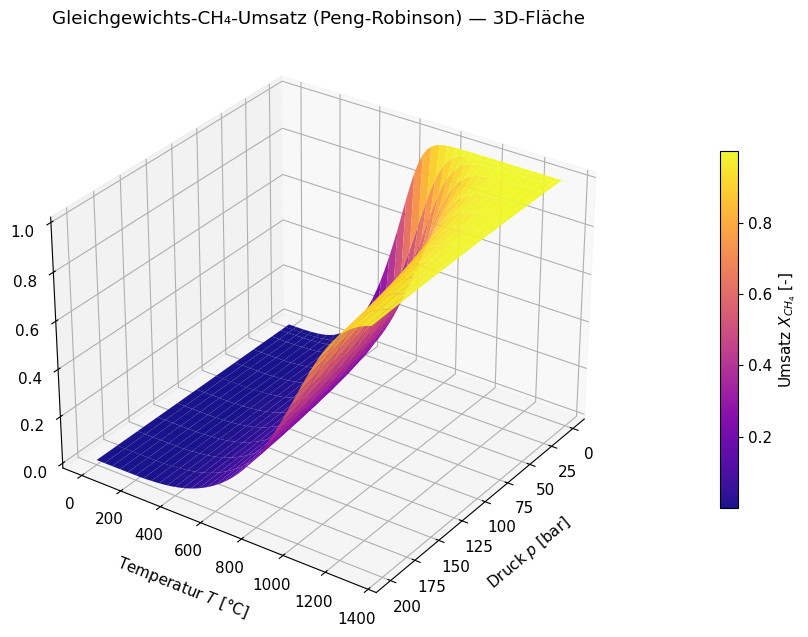

Plot gespeichert: CH4_conv_PR_surface.pdf


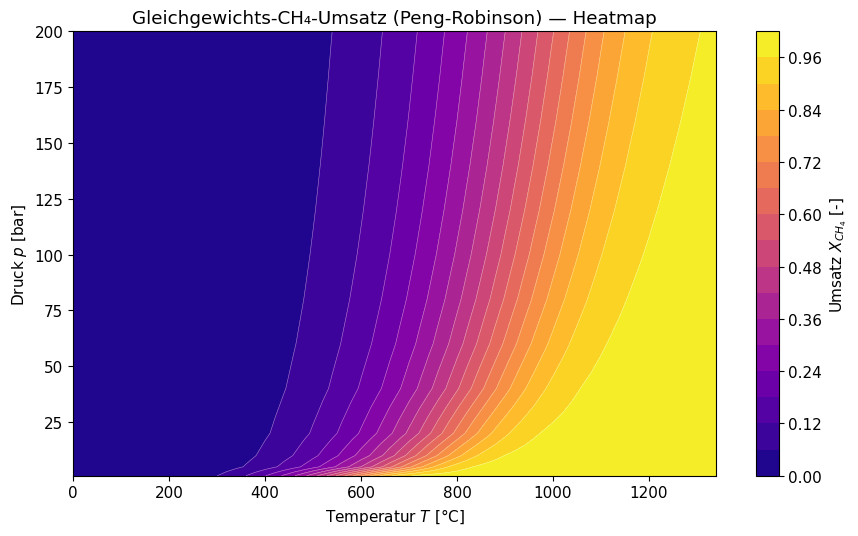

Plot gespeichert: CH4_conv_PR_heatmap.pdf


In [11]:
# Gleichgewichtsberechnung mit Peng-Robinson — 2D ueber (p, T)
Xconv_PR = np.full((np_, nT), np.nan)

for ip, p_now in enumerate(p_vec):
    for it, T_now in enumerate(T_range):
        try:
            g_pr.TPX = T_now, p_now, X_dict
            g_pr.equilibrate('TP')
            w_CH4 = g_pr['CH4'].Y[0]
            umsatz = (w_CH4_in_pr - w_CH4) / w_CH4_in_pr
            Xconv_PR[ip, it] = np.clip(umsatz, 0.0, 1.0)
        except Exception:
            Xconv_PR[ip, it] = np.nan

print('Peng-Robinson Berechnung abgeschlossen \u2713')
print(f'  Min. Umsatz (PR): {np.nanmin(Xconv_PR):.3f}')
print(f'  Max. Umsatz (PR): {np.nanmax(Xconv_PR):.3f}')

# 3D-Oberflaechenplot (PR)
fig_pr1, ax_pr1 = plt.subplots(subplot_kw={'projection': '3d'}, figsize=(9, 6.5))
surf_pr = ax_pr1.plot_surface(P_grid.T, T_grid.T, Xconv_PR.T,
                               cmap='plasma', edgecolor='none', alpha=0.95)
ax_pr1.set_xlabel('Druck $p$ [bar]',     labelpad=10)
ax_pr1.set_ylabel('Temperatur $T$ [\u00b0C]', labelpad=10)
ax_pr1.set_zlabel('Umsatz $X_{CH_4}$ [-]', labelpad=10)
ax_pr1.set_title('Gleichgewichts-CH\u2084-Umsatz (Peng-Robinson) \u2014 3D-Fl\u00e4che')
ax_pr1.view_init(elev=30, azim=35)
fig_pr1.colorbar(surf_pr, ax=ax_pr1, pad=0.12, shrink=0.6).set_label('Umsatz $X_{CH_4}$ [-]')
plt.tight_layout()
fig_pr1.savefig('CH4_conv_PR_surface.pdf', dpi=150)
plt.show()
print('Plot gespeichert: CH4_conv_PR_surface.pdf')

# Heatmap (PR)
fig_pr2, ax_pr2 = plt.subplots(figsize=(9, 5.5))
cf_pr = ax_pr2.contourf(T_grid, P_grid, Xconv_PR, levels=18, cmap='plasma')
ax_pr2.contour(T_grid, P_grid, Xconv_PR, levels=18,
               colors='white', linewidths=0.4, alpha=0.5)
ax_pr2.set_xlabel('Temperatur $T$ [\u00b0C]')
ax_pr2.set_ylabel('Druck $p$ [bar]')
ax_pr2.set_title('Gleichgewichts-CH\u2084-Umsatz (Peng-Robinson) \u2014 Heatmap')
fig_pr2.colorbar(cf_pr, ax=ax_pr2).set_label('Umsatz $X_{CH_4}$ [-]')
plt.tight_layout()
fig_pr2.savefig('CH4_conv_PR_heatmap.pdf', dpi=150)
plt.show()
print('Plot gespeichert: CH4_conv_PR_heatmap.pdf')


## 9. Vergleich: Idealgas (GRI30) vs. Peng-Robinson

Drei Darstellungen:
1. **Absolute Differenz** dX = X_PR - X_Ideal (Heatmap)
2. **Kurvenscharen** bei ausgewaehlten Druecken: Idealgas vs. PR
3. **Relative Abweichung** |dX| / X_Ideal [%] (Heatmap, nur fuer X_Ideal > 0.05)

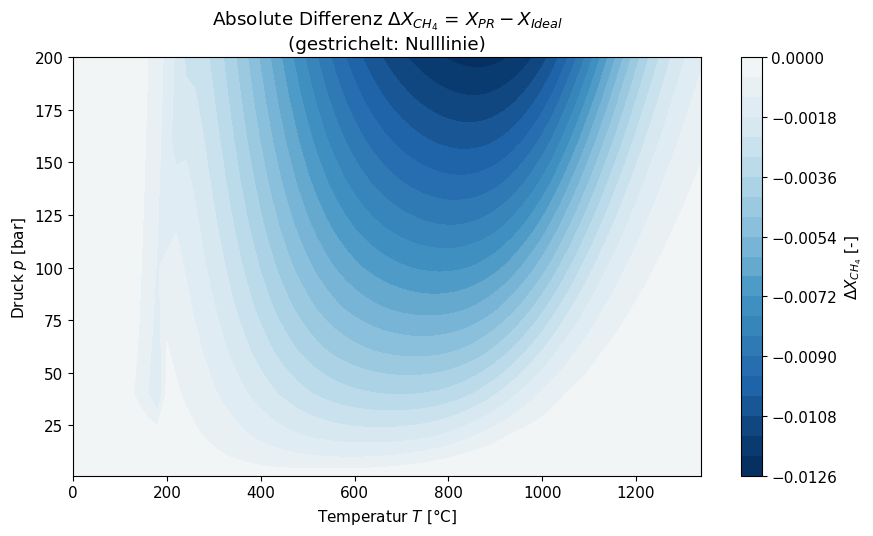

Plot gespeichert: Vergleich_dX_heatmap.pdf
  Max. |dX|:        0.01222
  Mittl. |dX|:      0.00300
  |dX| bei 200 bar: 0.00655
  |dX| bei   1 bar: 0.00005


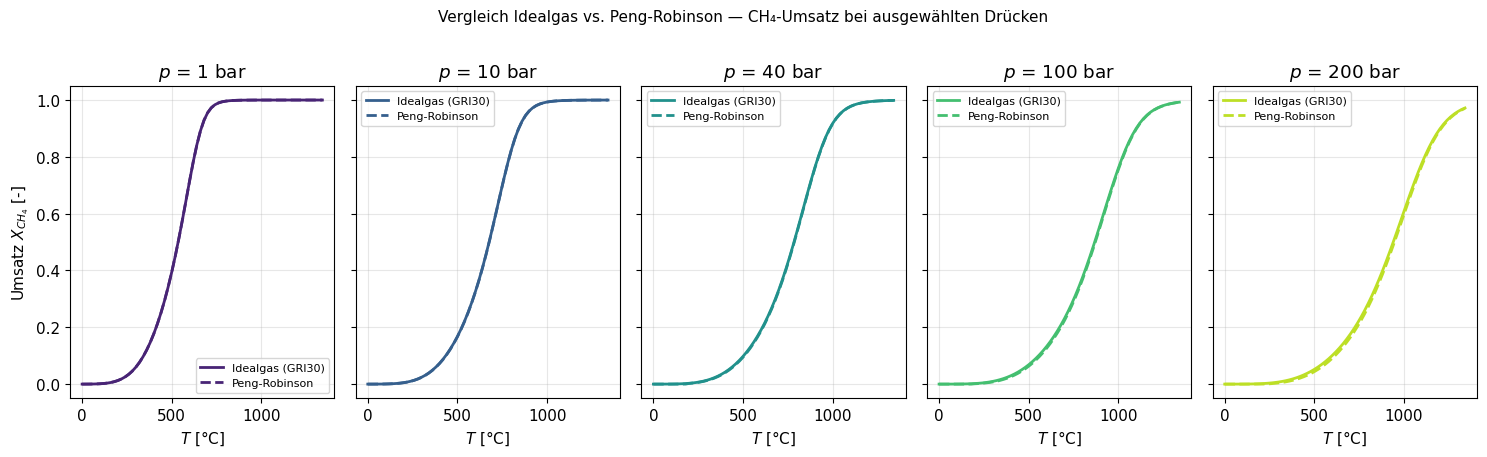

Plot gespeichert: Vergleich_Kurven.pdf


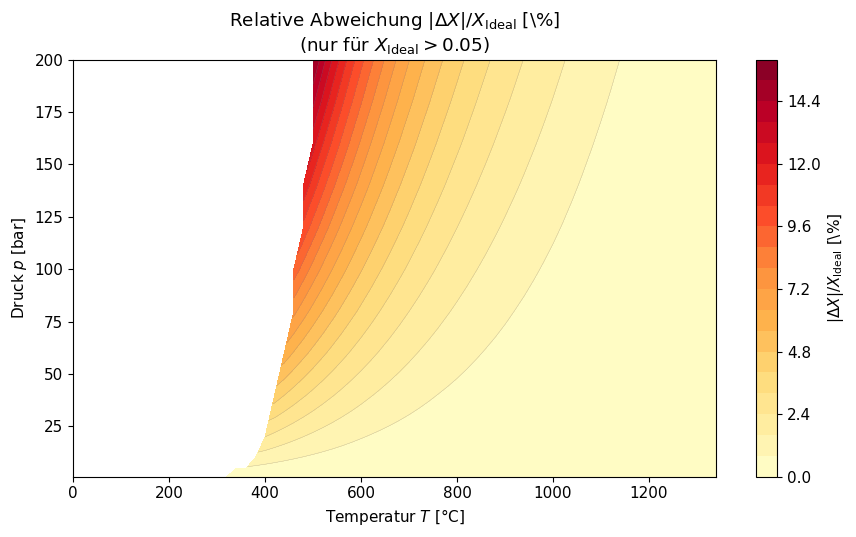

Plot gespeichert: Vergleich_RelAbw_heatmap.pdf

Max. relative Abweichung:  15.28 %
Mittl. relative Abweichung: 1.74 %


In [12]:
# 1. Differenz-Heatmap dX = X_PR - X_Ideal
dX = Xconv_PR - Xconv   # positiv: PR liefert hoeheren Umsatz als Idealgas

fig_d1, ax_d1 = plt.subplots(figsize=(9, 5.5))
lim = max(np.nanmax(np.abs(dX)), 1e-6)
cf_d = ax_d1.contourf(T_grid, P_grid, dX, levels=20,
                       cmap='RdBu_r', vmin=-lim, vmax=lim)
ax_d1.contour(T_grid, P_grid, dX, levels=[0],
              colors='black', linewidths=1.5, linestyles='--')
ax_d1.set_xlabel('Temperatur $T$ [\u00b0C]')
ax_d1.set_ylabel('Druck $p$ [bar]')
ax_d1.set_title('Absolute Differenz $\\Delta X_{CH_4}$ = $X_{PR} - X_{Ideal}$\n(gestrichelt: Nulllinie)')
fig_d1.colorbar(cf_d, ax=ax_d1).set_label('$\\Delta X_{CH_4}$ [-]')
plt.tight_layout()
fig_d1.savefig('Vergleich_dX_heatmap.pdf', dpi=150)
plt.show()
print('Plot gespeichert: Vergleich_dX_heatmap.pdf')
print(f'  Max. |dX|:        {np.nanmax(np.abs(dX)):.5f}')
print(f'  Mittl. |dX|:      {np.nanmean(np.abs(dX)):.5f}')
print(f'  |dX| bei 200 bar: {np.nanmean(np.abs(dX[-1,:])):.5f}')
print(f'  |dX| bei   1 bar: {np.nanmean(np.abs(dX[0,:])):.5f}')

# 2. Kurvenscharen bei ausgewaehlten Druecken
p_show   = [1, 10, 50, 100, 200]
colors_p = plt.cm.viridis(np.linspace(0.1, 0.9, len(p_show)))

fig_d2, axes = plt.subplots(1, len(p_show), figsize=(15, 4.5), sharey=True)
for ax_sub, c, p_target in zip(axes, colors_p, p_show):
    ip = int(np.argmin(np.abs(p_bar - p_target)))
    ax_sub.plot(T_C, Xconv[ip, :],    color=c, lw=2.0, ls='-',  label='Idealgas (GRI30)')
    ax_sub.plot(T_C, Xconv_PR[ip, :], color=c, lw=2.0, ls='--', label='Peng-Robinson')
    ax_sub.set_title(f'$p$ = {p_bar[ip]:.0f} bar')
    ax_sub.set_xlabel('$T$ [\u00b0C]')
    ax_sub.grid(alpha=0.3)
    ax_sub.legend(fontsize=8)

axes[0].set_ylabel('Umsatz $X_{CH_4}$ [-]')
fig_d2.suptitle('Vergleich Idealgas vs. Peng-Robinson \u2014 CH\u2084-Umsatz bei ausgew\u00e4hlten Dr\u00fccken',
                fontsize=11, y=1.01)
plt.tight_layout()
fig_d2.savefig('Vergleich_Kurven.pdf', dpi=150, bbox_inches='tight')
plt.show()
print('Plot gespeichert: Vergleich_Kurven.pdf')

# 3. Relative Abweichung |dX| / X_Ideal [%]
mask_valid = Xconv > 0.05
rel_abw = np.full_like(dX, np.nan)
rel_abw[mask_valid] = np.abs(dX[mask_valid]) / Xconv[mask_valid] * 100

fig_d3, ax_d3 = plt.subplots(figsize=(9, 5.5))
cf_r = ax_d3.contourf(T_grid, P_grid, rel_abw, levels=20, cmap='YlOrRd')
ax_d3.contour(T_grid, P_grid, rel_abw, levels=20,
              colors='gray', linewidths=0.3, alpha=0.5)
ax_d3.set_xlabel('Temperatur $T$ [\u00b0C]')
ax_d3.set_ylabel('Druck $p$ [bar]')
ax_d3.set_title('Relative Abweichung $|\\Delta X| / X_\\mathrm{Ideal}$ [\\%]\n(nur f\u00fcr $X_\\mathrm{Ideal} > 0.05$)')
fig_d3.colorbar(cf_r, ax=ax_d3).set_label('$|\\Delta X| / X_\\mathrm{Ideal}$ [\\%]')
plt.tight_layout()
fig_d3.savefig('Vergleich_RelAbw_heatmap.pdf', dpi=150)
plt.show()
print('Plot gespeichert: Vergleich_RelAbw_heatmap.pdf')
print(f'\nMax. relative Abweichung:  {np.nanmax(rel_abw):.2f} %')
print(f'Mittl. relative Abweichung: {np.nanmean(rel_abw):.2f} %')
